In [ ]:
# This is the computer program code, use to analyse the data from the cosmic on air project taken by the RadiaCode Detector
# Valen Lebepe
# 13 September 2025


In [ ]:
# Importing relevant python libraries
import pandas as pd    # importing pandas
import numpy as np     # importing numpy
import matplotlib.pyplot as plt       # importing matplotlib.pyplot for non-interactve plots
from scipy.optimize import curve_fit  # importing the curve fitting module from SciPy
import plotly.express as px           # Importing Plotly for interactive Plots


In [ ]:
# Importing in the data/ reading the DataFrame
df_d6cm = pd.read_excel("RadiaCode Distance Measurements.xlsx", sheet_name='6cm')    # 6cm distance data
df_d3cm = pd.read_excel("RadiaCode Distance Measurements.xlsx", sheet_name='3cm')    # 3m distance data
df_d1cm = pd.read_excel("RadiaCode Distance Measurements.xlsx", sheet_name='1cm')    # 2m distance data
df_db = pd.read_excel("RadiaCode Distance Measurements.xlsx", sheet_name ='background')    # background distance data

df_l = pd.read_excel("RadiaCode Lead Measurements.xlsx", sheet_name='lead measurement')     # lead data
df_lb = pd.read_excel("RadiaCode Lead Measurements.xlsx", sheet_name='background measurement')     # background lead data
df_l.sample()

,Time,Timestamp,Event,"Count Rate, cps","Dose rate, R/h","Dose Rate Error, %",Dose Rate Alarm,Dose Alarm,"Duration of dose accumulation, sec."
41,2025-08-18 14:07:35.208,133999996552080000,NaN,8.96875,0.00004,13.2,0,0,NaN


In [ ]:
# Cleaning and filtering the data

# Removing un-needed columns
df_d6cm=df_d6cm.drop(["Timestamp","Time","Event","Dose rate, R/h", "Dose Rate Error, %", "Dose Rate Alarm","Dose Alarm","Duration of dose accumulation, sec."], axis =1)
df_d3cm=df_d3cm.drop(["Timestamp","Time","Event","Dose rate, R/h", "Dose Rate Error, %", "Dose Rate Alarm","Dose Alarm","Duration of dose accumulation, sec."], axis =1)
df_d1cm=df_d1cm.drop(["Timestamp","Time","Event","Dose rate, R/h", "Dose Rate Error, %", "Dose Rate Alarm","Dose Alarm","Duration of dose accumulation, sec."], axis =1)
df_db=df_db.drop(["Timestamp","Time","Event","Dose rate, R/h", "Dose Rate Error, %", "Dose Rate Alarm","Dose Alarm","Duration of dose accumulation, sec."], axis =1)

df_l=df_l.drop(["Timestamp","Time","Event","Dose rate, R/h", "Dose Rate Error, %", "Dose Rate Alarm","Dose Alarm","Duration of dose accumulation, sec."], axis =1)
df_lb=df_lb.drop(["Timestamp","Time","Event","Dose rate, R/h", "Dose Rate Error, %", "Dose Rate Alarm","Dose Alarm","Duration of dose accumulation, sec."], axis =1)

#Renaiming Columnms
df_d6cm.columns=["cps"]
df_d3cm.columns=["cps"]
df_d1cm.columns=["cps"]
df_db.columns=["cps"]


df_l.columns=["cps"]
df_lb.columns=["cps"]

# Converting the columns to numerics
df_d6cm["cps"]= pd.to_numeric(df_d6cm["cps"], errors="coerce")
df_d3cm["cps"]= pd.to_numeric(df_d3cm["cps"], errors="coerce")
df_d1cm["cps"]= pd.to_numeric(df_d1cm["cps"], errors="coerce")

df_l["cps"]= pd.to_numeric(df_l["cps"], errors="coerce")
df_lb["cps"]= pd.to_numeric(df_lb["cps"], errors="coerce")


# Drop any rows that have missing or invalid values
print(f"The 6cm distance measurements have [{df_d6cm.isna().sum()}] missing rows")
print(f"\nThe 3cm distance measurements have [{df_d3cm.isna().sum()}] missing rows")
print(f"\nThe 1cm distance measurements have [{df_d1cm.isna().sum()}] missing rows")
print(f"\nThe distance background measurements have [{df_db.isna().sum()}] missing rows")

print(f"\nThe lead measurements have [{df_l.isna().sum()}] missing rows")
print(f"\nThe lead background measurements have [{df_lb.isna().sum()}] missing rows")

df_d6cm=df_d6cm.dropna()
df_d3cm=df_d3cm.dropna()
df_d1cm=df_d1cm.dropna()
df_db=df_db.dropna()

df_l=df_l.dropna()
df_lb=df_lb.dropna()


The 6cm distance measurements have [cps    0
dtype: int64] missing rows

The 3cm distance measurements have [cps    0
dtype: int64] missing rows

The 1cm distance measurements have [cps    0
dtype: int64] missing rows

The distance background measurements have [cps    0
dtype: int64] missing rows

The lead measurements have [cps    0
dtype: int64] missing rows

The lead background measurements have [cps    0
dtype: int64] missing rows


In [ ]:
# Creating a dataframe of the Elapsed time (in seconds) for which each measurements were taken
time_d6cm =pd.DataFrame(np.linspace(0,857.787,len(df_d6cm)), columns=["time"])    # Elapsed time for 6cm distance measurements
time_d3cm =pd.DataFrame(np.linspace(0,662.93,len(df_d3cm)), columns=["time"])    # Elapsed time for 3cm distance measurements
time_d1cm =pd.DataFrame(np.linspace(0,1227.89,len(df_d1cm)), columns=["time"])    # Elapsed time for 1cm distance measurements
time_db =pd.DataFrame(np.linspace(0,2519.26,len(df_db)), columns=["time"])    # Elapsed time for distance background measurements

time_l =pd.DataFrame(np.linspace(0,2519.26,len(df_l)), columns=["time"])    # Elapsed time for lead measurements
time_lb =pd.DataFrame(np.linspace(0,2519.26,len(df_lb)), columns=["time"])    # Elapsed time for lead measurements


In [ ]:
# Visualizing the raw data data using plotly

fig1 =px.scatter(x=time_d6cm["time"], y = df_d6cm["cps"], title="The Plot of Counts vs Time for 6 cm Distance Measurements",labels = {"x":"Elapsed time[s]", "y":"counts per second"})
fig1.show()
fig2 =px.scatter(x=time_d3cm["time"], y = df_d3cm["cps"], title="The Plot of Counts vs Time for 3 cm Distance Measurements",labels = {"x":" Elapsed time[s]", "y":"counts per second"})
fig2.show()
fig3 =px.scatter(x=time_d1cm["time"], y = df_d1cm["cps"], title="The Plot of Counts vs Time for 1 cm Distance Measurements",labels = {"x":"Elapsed time[s]", "y":"counts per second"})
fig3.show()
fig4 =px.scatter(x=time_db["time"], y = df_db["cps"], title="The Plot of Counts vs Time for background Distance Measurements",labels = {"x":"Elapsed time[s]", "y":"counts per second"})
fig4.show()

fig5 =px.scatter(x=time_l["time"], y = df_l["cps"], title="The Plot of Counts vs Time for lead Measurements",labels = {"x":"Elapsed time[s]", "y":"counts per second"})
fig5.show()
fig6 =px.scatter(x=time_lb["time"], y = df_lb["cps"], title="The Plot of Counts vs Time for background lead Measurements",labels = {"x":"Elapsed time[s]", "y":"counts per second"})
fig6.show()



In [ ]:
# Finding the mean value of the counts per second (R):

# For 6cm distane
R_d6cm = df_d6cm['cps'].mean()
u_R_d6cm = df_d6cm['cps'].std()/np.sqrt(len(df_d6cm))
print(f"The background un-corrected R from 6cm is: {R_d6cm:.3f} ± {u_R_d6cm:.3} cps") # Printing out the results

# For 3cm distane
R_d3cm = df_d3cm['cps'].mean()
u_R_d3cm = df_d3cm['cps'].std()/np.sqrt(len(df_d3cm))
print(f"\nThe background un-corrected R from 3cm is: {R_d3cm:.3f} ± {u_R_d3cm:.3} cps") # Printing out the results

# For 1cm distane
R_d1cm = df_d1cm['cps'].mean()
u_R_d1cm = df_d1cm['cps'].std()/np.sqrt(len(df_d1cm))
print(f"\nThe background un-corrected R from 1cm is: {R_d1cm:.3f} ± {u_R_d1cm:.3} cps") # Printing out the results

# For distane distance background
R_db = df_db['cps'].mean()
u_R_db = df_db['cps'].std()/np.sqrt(len(df_db))
print(f"\nThe background R for distance measurement is: {R_db:.3f} ± {u_R_db:.3} cps") # Printing out the results

# For lead measuremenst
R_l = df_l['cps'].mean()
u_R_l = df_l['cps'].std()/np.sqrt(len(df_l))
print(f"\nThe background un-corrected R from lead measurements is: {R_l:.3f} ± {u_R_l:.3} cps")# Printing out the results

# For lead measurements background
R_lb = df_lb['cps'].mean()
u_R_lb = df_lb['cps'].std()/np.sqrt(len(df_lb))
print(f"\nThe background R from lead measurements is: {R_lb:.3f} ± {u_R_lb:.3} cps")# Printing out the results



The background un-corrected R from 6cm is: 24.198 ± 0.171 cps

The background un-corrected R from 3cm is: 52.662 ± 0.162 cps

The background un-corrected R from 1cm is: 162.742 ± 0.27 cps

The background R for distance measurement is: 7.323 ± 0.0452 cps

The background un-corrected R from lead measurements is: 9.070 ± 0.0492 cps

The background R from lead measurements is: 4.311 ± 0.0317 cps


In [ ]:
# Calulating the background corrected mean count rates (R)

# For 6cm distane
Rc_d6cm = R_d6cm - R_db
u_Rc_d6cm = np.sqrt((u_R_d6cm**2) + (u_R_db**2))
print(f"\nThe background corrected R from 6cm is: {Rc_d6cm:.3f} ± {u_Rc_d6cm:.3} cps") # Printing out the results

# For 3cm distace
Rc_d3cm = R_d3cm - R_db
u_Rc_d3cm = np.sqrt((u_R_d3cm**2) + (u_R_db**2))
print(f"\nThe background corrected R from 3cm is: {Rc_d3cm:.3f} ± {u_Rc_d3cm:.3} cps") # Printing out the results

# For 3cm distace
Rc_d1cm = R_d1cm - R_db
u_Rc_d1cm = np.sqrt((u_R_d1cm**2) + (u_R_db**2))
print(f"\nThe background corrected R from 1cm is: {Rc_d1cm:.3f} ± {u_Rc_d1cm:.3} cps") # Printing out the results

# For lead measurements
Rc_l = R_l - R_lb
u_Rc_l = np.sqrt((u_R_l**2) + (u_R_lb**2))
print(f"\nThe background corrected R from lead measurements is: {Rc_l:.3f} ± {u_Rc_l:.3} cps") # Printing out the results





The background corrected R from 6cm is: 16.874 ± 0.177 cps

The background corrected R from 3cm is: 45.339 ± 0.168 cps

The background corrected R from 1cm is: 155.419 ± 0.273 cps

The background corrected R from lead measurements is: 4.758 ± 0.0585 cps


In [ ]:
# Calculating the solid angle subtended

# Function for solid angle
def solid_angle_square(L, d):
    return L**2/(np.pi*4*d**2)

def solid_angle_uncertainty(L, u_L, d, u_d):
    return solid_angle_square(L,d)*np.sqrt((2*u_L/L)**2 + (2*u_d/d)**2)


# constants
A_list = np.array([0.019e6, 0.019e6, 0.019e6]) # List of measured activities of 60Co
A = A_list.mean()  # Value of the activity of 60 Co
u_A =  0.05*A   # Vlaue of the uncertainty of 60 Co
lead_height = 5.1 # Height of the Lead
u_lead_height = 0.019 # Uncertainty of Height of the Lead
lead_hole_radius =  0.2  # Radius of the lead hole
u_lead_hole_radius =  0.01  # Uncertainty of Radius of the lead hole
L = 1.1 # Lenghth of the detector sensor
u_L = 0.1/(2*np.sqrt(3))   # Uncertainty of the detector sensor length
u_d = 0.2/(2*np.sqrt(6))  # Uncertainty of distance between source and detector     - Type b evaluation

# For 6cm distance
solid_6cm =  solid_angle_square(L,6) # solid angle at 6cm
u_solid_6cm = solid_angle_uncertainty(L, u_L, 6, u_d)  # uncertainty of solid angle at 6cm
print(solid_6cm,"+/-", u_solid_6cm)

# For 3cm distance
solid_3cm =  solid_angle_square(L,3) # solid angle at 3cm
u_solid_3cm = solid_angle_uncertainty(L, u_L, 3, u_d)  # uncertainty of solid angle at 3cm
print(solid_3cm,"+/-", u_solid_3cm)

# For 1cm distance
solid_1cm = solid_angle_square(L,1)# solid angle at 6cm
u_solid_1cm = solid_angle_uncertainty(L, u_L, 1, u_d)  # uncertainty of solid angle at 1cm
print(solid_1cm,"+/-",u_solid_1cm)

# For lead measurements
def solid_angle_square(r, d):
  return r**2/(4*d**2)

def solid_angle_uncertainty(r, u_r, d, u_d):
    return solid_angle_square(r,d)*np.sqrt((2*u_r/r)**2 + (2*u_d/d)**2)

solid_l = solid_angle_square(lead_hole_radius,lead_height)  # solid angle at the lead height
u_solid_l = solid_angle_uncertainty(lead_hole_radius, u_lead_hole_radius, lead_height, u_lead_height)  # uncertainty of solid angle at 6cm
print(solid_l,"+/-",u_solid_l)
#c=0.004825795878762362 +/- 0.00019625215551965063


0.0026746872380721304 +/- 0.00014502641880176018
0.010698748952288522 +/- 0.0006325450792356597
0.09628874057059669 +/- 0.009346203798743664
0.0003844675124951943 +/- 3.8553326159594004e-05


In [ ]:
# Calculating the efficiencies of the detector at different distances

# For 6cm distance
e_6cm = (Rc_d6cm)/(A*solid_6cm)
rel_u_e_6cm = np.sqrt((u_Rc_d6cm/Rc_d6cm)**2 + (u_A/A)**2 + (u_solid_6cm/solid_6cm)**2)   #relative uncertainty
u_e_6cm = e_6cm * rel_u_e_6cm
print(f"The efficiency of the detector at 6cm is: {e_6cm} ± {u_e_6cm}")

# For 3m distance
e_3cm = (Rc_d3cm) / (A * solid_3cm)
rel_u_e_3cm = np.sqrt((u_Rc_d3cm / Rc_d3cm)**2 + (u_A / A)**2 + (u_solid_3cm / solid_3cm)**2)     #relative uncertainty
u_e_3cm = e_3cm * rel_u_e_3cm
print(f"\nThe efficiency of the detector at 3cm is: {e_3cm} ± {u_e_3cm}")

# For 1cm distance
e_1cm = (Rc_d1cm ) / (A * solid_1cm)
rel_u_e_1cm = np.sqrt((u_Rc_d1cm / Rc_d1cm)**2 + (u_A / A)**2 + (u_solid_1cm / solid_1cm)**2)     #relative uncertainty
u_e_1cm = e_1cm * rel_u_e_1cm
print(f"\nThe efficiency of the detector at 1cm is: {e_1cm} ± {u_e_1cm}")

# For lead measurements
e_l = (Rc_l * 4 * np.pi) / (A * solid_l)
rel_u_e_l = np.sqrt((u_Rc_l / Rc_l)**2 + (u_A / A)**2 + (u_solid_l / solid_l)**2)     #relative uncertainty
u_e_l = e_l * rel_u_e_l
print(f"\nThe efficiency of the detector for lead measurements is: {e_l} ± {u_e_l}")


The efficiency of the detector at 6cm is: 0.3320498864566942 ± 0.02473639460829098

The efficiency of the detector at 3cm is: 0.22304023411923618 ± 0.01729008069304668

The efficiency of the detector at 1cm is: 0.08495234451132472 ± 0.009276772732152584

The efficiency of the detector for lead measurements is: 8.185755496614592 ± 0.9227234296787864


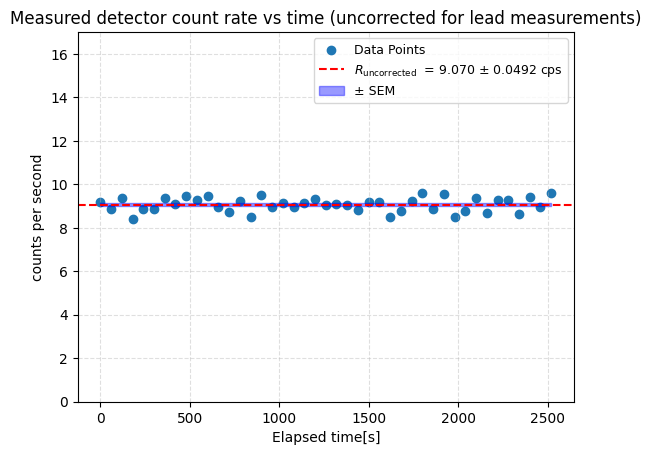

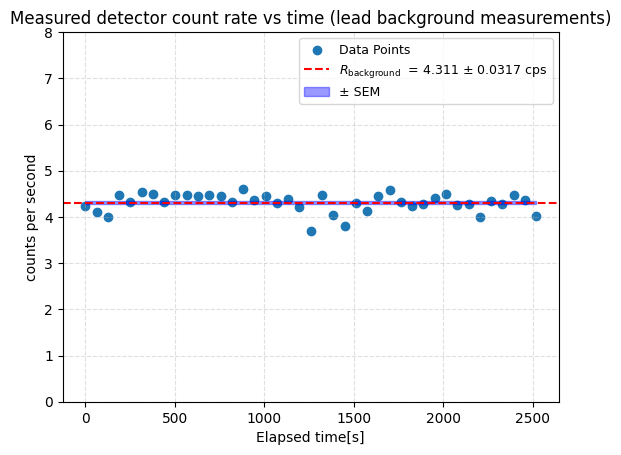

In [ ]:
# Visualising the raw data using Matplotlib

#For lead measurement distance
plt.scatter(time_l["time"], df_l["cps"], label ="Data Points")
plt.axhline(df_l["cps"].mean(), color='red', linestyle='--', label=fr"$R_{{\text{{uncorrected}}}}$ ​ = {R_l:.3f} ± {u_R_l:.3} cps")    # the mean value of the data points
plt.fill_between(time_l["time"], R_l-u_R_l, R_l+u_R_l, color='blue', alpha=0.4, label="± SEM")   # # Shaded band for uncertainty
plt.title("Measured detector count rate vs time (uncorrected for lead measurements)" )
plt.ylim(0,17)
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.xlabel("Elapsed time[s]")
plt.ylabel("counts per second")
plt.legend(fontsize= 9)
plt.savefig("Measured detector count rate vs time (uncorrected for lead measurements).png")
plt.show()

# For lead background
plt.scatter(time_lb["time"], df_lb["cps"], label ="Data Points")
plt.axhline(df_lb["cps"].mean(), color='red', linestyle='--', label=fr"$R_{{\text{{background}}}}$ ​ = {R_lb:.3f} ± {u_R_lb:.3} cps")    # the mean value of the data points
plt.fill_between(time_lb["time"], R_lb-u_R_lb, R_lb+u_R_lb, color='blue', alpha=0.4, label="± SEM")   # # Shaded band for uncertainty
plt.title("Measured detector count rate vs time (lead background measurements)" )
plt.ylim(0,8)
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.xlabel("Elapsed time[s]")
plt.ylabel("counts per second")
plt.legend(fontsize= 9)
plt.savefig("Measured detector count rate vs time (lead background measurements).png")
plt.show()

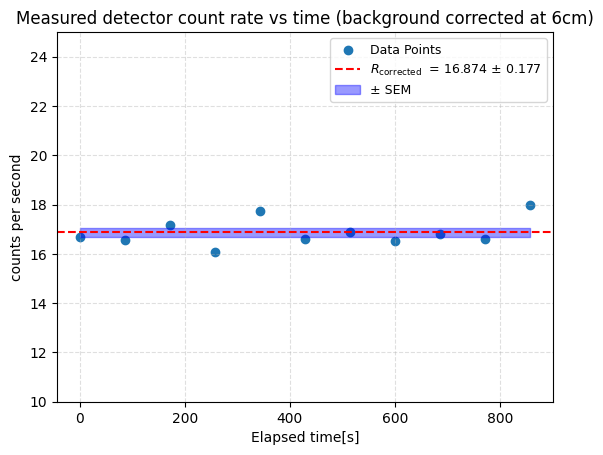

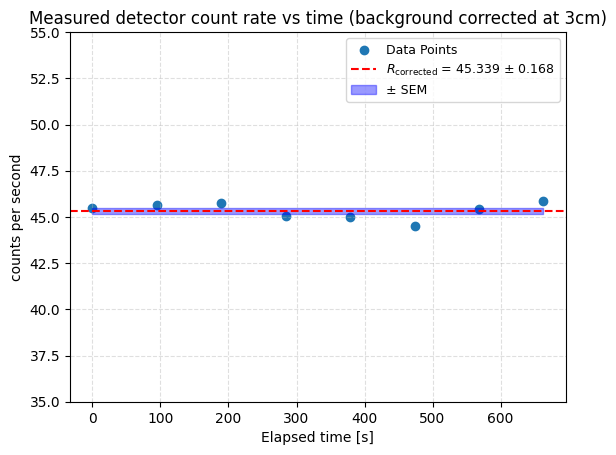

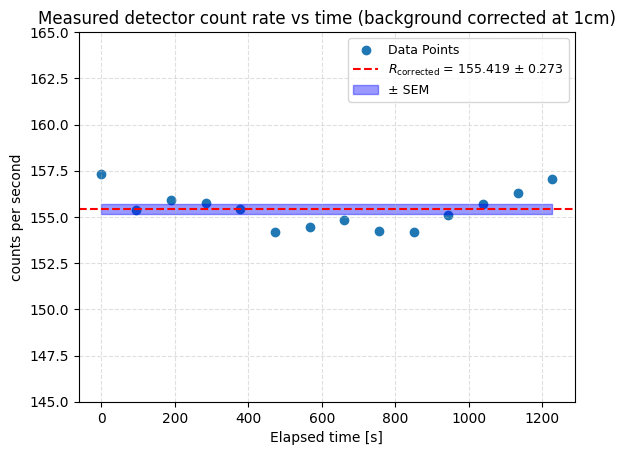

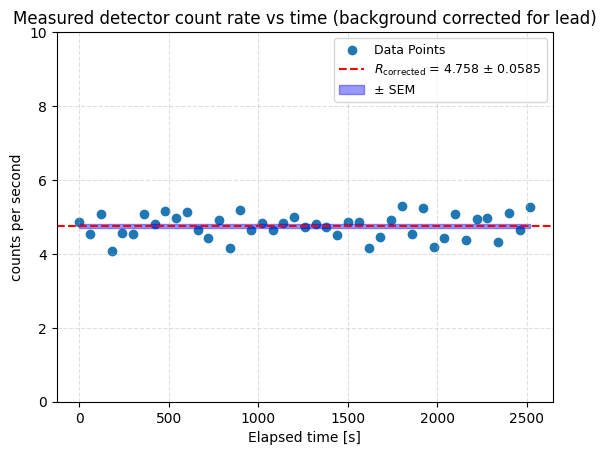

In [ ]:
# Visuliasing data with R background corrcted, and measured efficiencies

#For 6cm distance
plt.scatter(time_d6cm["time"], df_d6cm["cps"]-R_db, label ="Data Points")
plt.axhline(Rc_d6cm, color='red', linestyle='--', label=fr"$R_{{\text{{corrected}}}}$ ​ = {Rc_d6cm:.3f} ± {u_Rc_d6cm:.3}")    # the mean value of the data points
plt.fill_between(time_d6cm["time"], Rc_d6cm-u_Rc_d6cm, Rc_d6cm+u_Rc_d6cm, color='blue', alpha=0.4, label="± SEM")   # # Shaded band for uncertainty
plt.title("Measured detector count rate vs time (background corrected at 6cm)" )
plt.ylim(10,25)
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.xlabel("Elapsed time[s]")
plt.ylabel("counts per second")
plt.legend(fontsize= 9)
plt.savefig("Measured detector count rate vs time (corrected at 6cm).png")
plt.show()

# For 3 cm distance
plt.scatter(time_d3cm["time"], df_d3cm["cps"] - R_db, label="Data Points")
plt.axhline(Rc_d3cm, color='red', linestyle='--',label=fr"$R_{{\text{{corrected}}}}$ = {Rc_d3cm:.3f} ± {u_Rc_d3cm:.3}")
plt.fill_between(time_d3cm["time"], Rc_d3cm - u_Rc_d3cm, Rc_d3cm + u_Rc_d3cm,color='blue', alpha=0.4, label="± SEM")
plt.title("Measured detector count rate vs time (background corrected at 3cm)")
plt.ylim(35, 55)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Elapsed time [s]")
plt.ylabel("counts per second")
plt.legend(fontsize=9)
plt.savefig("Measured detector count rate vs time (background corrected at 3cm).png")
plt.show()

# For 1 cm distance
plt.scatter(time_d1cm["time"], df_d1cm["cps"] - R_db, label="Data Points")
plt.axhline(Rc_d1cm, color='red', linestyle='--', label=fr"$R_{{\text{{corrected}}}}$ = {Rc_d1cm:.3f} ± {u_Rc_d1cm:.3}")
plt.fill_between(time_d1cm["time"], Rc_d1cm - u_Rc_d1cm, Rc_d1cm + u_Rc_d1cm,color='blue', alpha=0.4, label="± SEM")
plt.title("Measured detector count rate vs time (background corrected at 1cm)")
plt.ylim(145, 165)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Elapsed time [s]")
plt.ylabel("counts per second")
plt.legend(fontsize=9)
plt.savefig("Measured detector count rate vs time (background corrected at 1cm).png")
plt.show()

# For lead measurement
plt.scatter(time_l["time"], df_l["cps"] - R_lb, label="Data Points")
plt.axhline(Rc_l, color='red', linestyle='--',label=fr"$R_{{\text{{corrected}}}}$ = {Rc_l:.3f} ± {u_Rc_l:.3}")
plt.fill_between(time_l["time"], Rc_l - u_Rc_l, Rc_l + u_Rc_l, color='blue', alpha=0.4, label="± SEM")
plt.title("Measured detector count rate vs time (background corrected for lead)")
plt.ylim(0, 10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Elapsed time [s]")
plt.ylabel("counts per second")
plt.legend(fontsize=9)
plt.savefig("Measured detector count rate vs time (background corrected for lead).png")
plt.show()


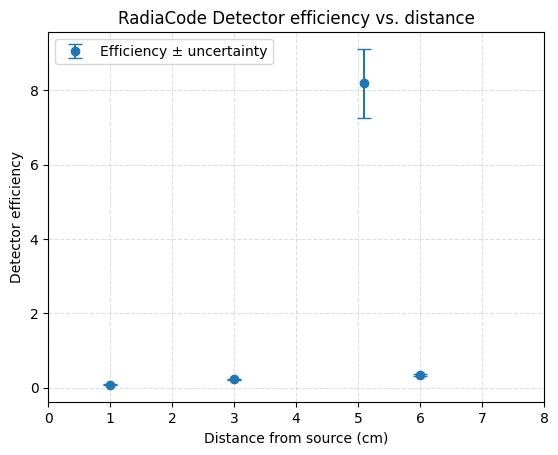

In [ ]:
# Plotting the efficiencies vs distance
d_values= np.array([6,3,1,lead_height])
eff = np.array([e_6cm,e_3cm,e_1cm,e_l])
u_eff = np.array([u_e_6cm,u_e_3cm,u_e_1cm,u_e_l])
plt.errorbar(d_values, eff, yerr=u_eff, fmt='o', capsize=5, label="Efficiency ± uncertainty")
plt.xlabel("Distance from source (cm)")
plt.xlim(0, 8)
plt.ylabel("Detector efficiency")
plt.title("RadiaCode Detector efficiency vs. distance")
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.legend()
plt.savefig("RadiaCode Detector efficiency vs. distance.png")
plt.show()


